# Step 1. Data Loading and Exploration:

- Understand the shape and structure of the dataset.
- Check for missing values and the distribution of the target variable.

In [73]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load datasets
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# Explore data
print("Train Dataset Shape:", train_df.shape)
print("Test Dataset Shape:", test_df.shape)
print("Train Columns:\n", train_df.columns)
print("Target Distribution:\n", train_df['churn_probability'].value_counts())

# Check missing values
missing_values = train_df.isnull().sum() / len(train_df) * 100
print("Missing Values (%):\n", missing_values[missing_values > 0])


Train Dataset Shape: (69999, 172)
Test Dataset Shape: (30000, 171)
Train Columns:
 Index(['id', 'circle_id', 'loc_og_t2o_mou', 'std_og_t2o_mou', 'loc_ic_t2o_mou',
       'last_date_of_month_6', 'last_date_of_month_7', 'last_date_of_month_8',
       'arpu_6', 'arpu_7',
       ...
       'sachet_3g_7', 'sachet_3g_8', 'fb_user_6', 'fb_user_7', 'fb_user_8',
       'aon', 'aug_vbc_3g', 'jul_vbc_3g', 'jun_vbc_3g', 'churn_probability'],
      dtype='object', length=172)
Target Distribution:
 churn_probability
0    62867
1     7132
Name: count, dtype: int64
Missing Values (%):
 loc_og_t2o_mou           1.002871
std_og_t2o_mou           1.002871
loc_ic_t2o_mou           1.002871
last_date_of_month_7     0.570008
last_date_of_month_8     1.047158
                          ...    
night_pck_user_7        74.478207
night_pck_user_8        73.689624
fb_user_6               74.902499
fb_user_7               74.478207
fb_user_8               73.689624
Length: 125, dtype: float64


# Step 2: Exploratory Data Analysis (EDA)

## 2.1 Univariate Analysis

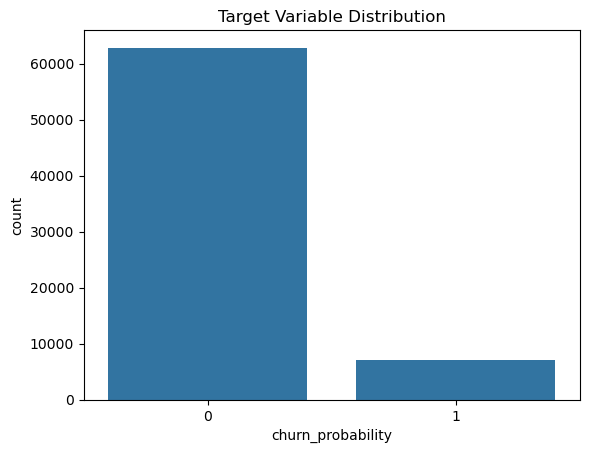

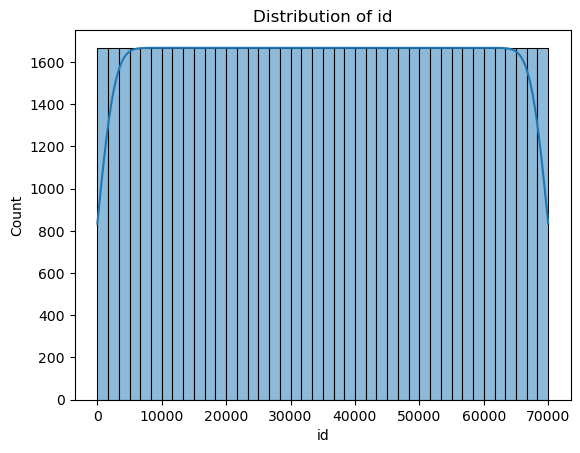

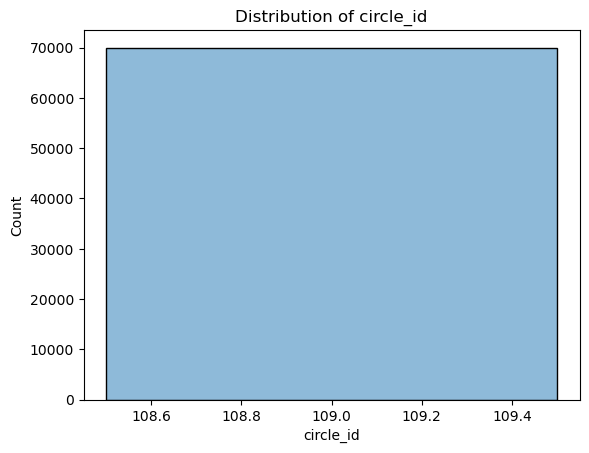

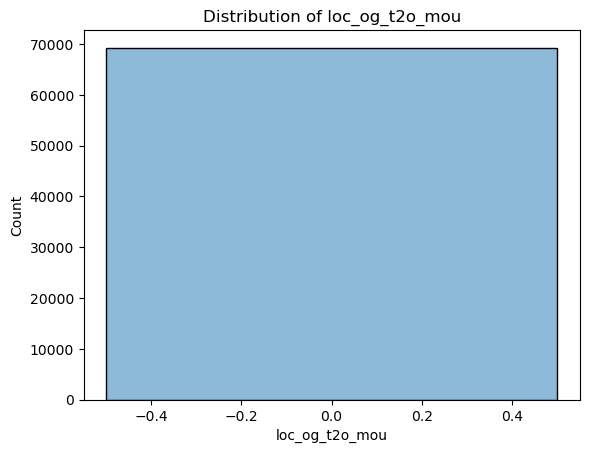

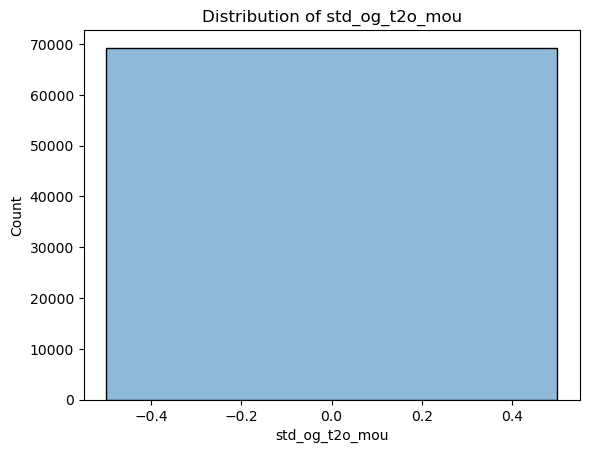

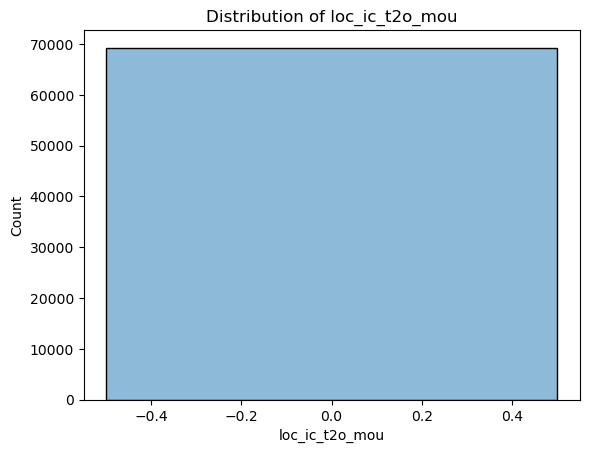

In [56]:
# Plot target variable
sns.countplot(x=train_df['churn_probability'])
plt.title('Target Variable Distribution')
plt.show()

# Visualize numerical features
numerical_columns = train_df.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_columns[:5]:  # Limit to first 5 for brevity
    sns.histplot(train_df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()


## 2.2 Correlation Analysis

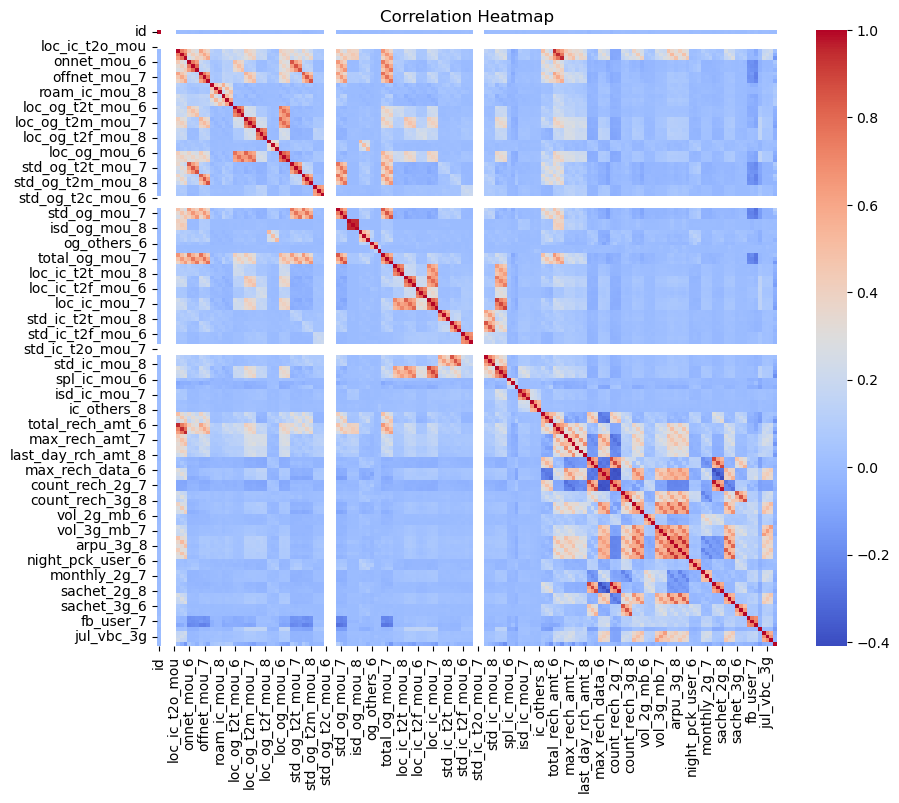

In [57]:
# Heatmap of correlations
corr = train_df[numerical_columns].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


## 2.3 Bivariate Analysis

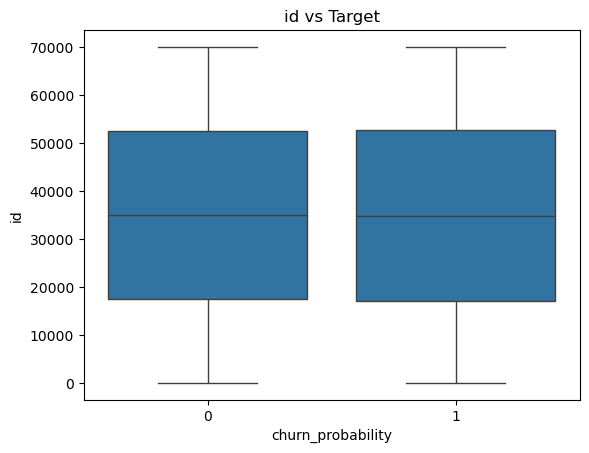

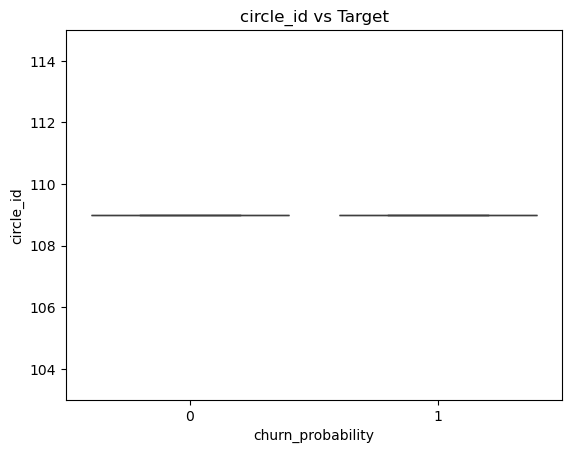

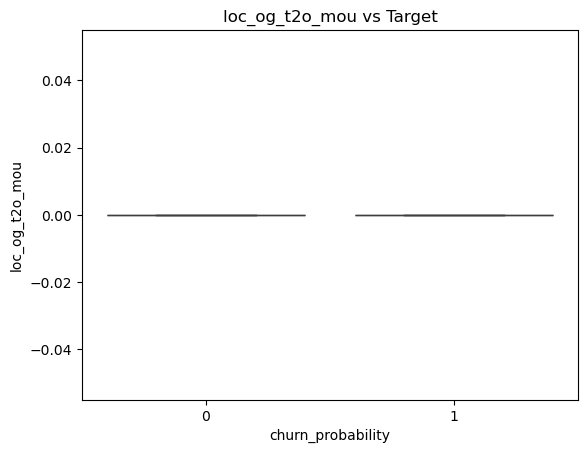

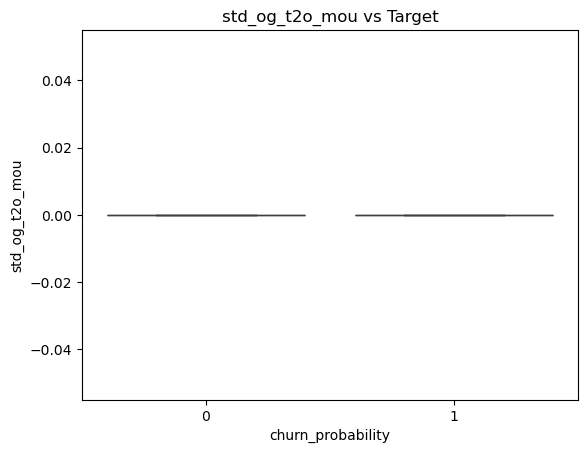

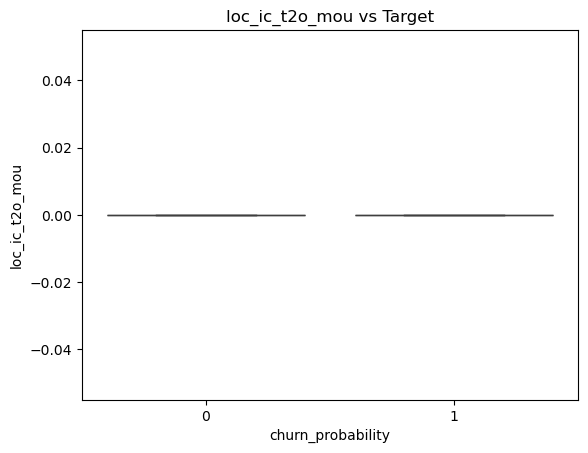

In [58]:
for col in numerical_columns[:5]:  # Limit to first 5 for brevity
    sns.boxplot(x='churn_probability', y=col, data=train_df)
    plt.title(f'{col} vs Target')
    plt.show()


# Step 3: Data Preprocessing

## 3.1 Handling Missing Values

In [74]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Drop columns with >60% missing values
train_df = train_df.dropna(axis=1, thresh=0.6 * len(train_df))
test_df = test_df.dropna(axis=1, thresh=0.6 * len(test_df))

# Fill missing numerical values with the mean
numerical_columns_train = train_df.select_dtypes(include=['float64', 'int64']).columns
numerical_columns_test = test_df.select_dtypes(include=['float64', 'int64']).columns

train_df[numerical_columns_train] = train_df[numerical_columns_train].fillna(train_df[numerical_columns_train].mean())
test_df[numerical_columns_test] = test_df[numerical_columns_test].fillna(test_df[numerical_columns_test].mean())

# Fill missing categorical values with 'Unknown'
categorical_columns_train = train_df.select_dtypes(include=['object']).columns
categorical_columns_test = test_df.select_dtypes(include=['object']).columns

train_df[categorical_columns_train] = train_df[categorical_columns_train].fillna('Unknown')
test_df[categorical_columns_test] = test_df[categorical_columns_test].fillna('Unknown')


## 3.2 Encoding Categorical Variables

In [75]:
label_encoder = LabelEncoder()

# Encode categorical variables consistently
for col in categorical_columns_train:
    combined_data = pd.concat([train_df[col], test_df[col]], axis=0)
    label_encoder.fit(combined_data)
    train_df[col] = label_encoder.transform(train_df[col])
    if col in categorical_columns_test:
        test_df[col] = label_encoder.transform(test_df[col])


## 3.3 Check Encoding Consistency

In [76]:
for col in categorical_columns_train:
    if col in categorical_columns_test:
        train_unique = set(train_df[col].unique())
        test_unique = set(test_df[col].unique())
        if train_unique != test_unique:
            print(f"Inconsistent encoding in column '{col}':")
            print(f" - Train unique values: {train_unique}")
            print(f" - Test unique values: {test_unique}")
        else:
            print(f"Column '{col}' has consistent encoding.")
    else:
        print(f"Column '{col}' is not present in the test dataset.")


Column 'last_date_of_month_6' has consistent encoding.
Column 'last_date_of_month_7' has consistent encoding.
Column 'last_date_of_month_8' has consistent encoding.
Column 'date_of_last_rech_6' has consistent encoding.
Column 'date_of_last_rech_7' has consistent encoding.
Column 'date_of_last_rech_8' has consistent encoding.


## 3.4 Separating Features and Target

In [77]:
X = train_df.drop(columns=['churn_probability', 'id'])
y = train_df['churn_probability']

X_test = test_df.drop(columns=['id'])


## 3.5 Train-Test Split and SMOTE

In [78]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Train-test split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


## 3.6 Scaling Data

In [79]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


# Step 4: Feature Engineering and Selection

## 4.1 Train Random Forest for Feature Importance

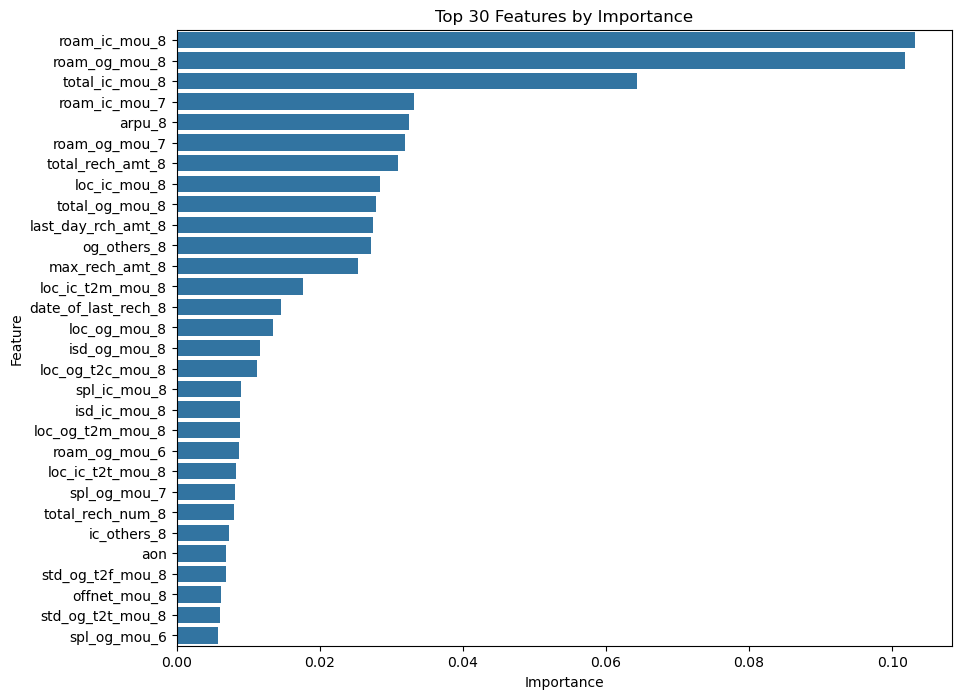

In [80]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train_smote, y_train_smote)

# Get feature importances
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

# Retain the top 30 features
top_features = feature_importances['Feature'][:30].tolist()

# Filter the dataset
X_train_top = pd.DataFrame(X_train_scaled, columns=X.columns)[top_features]
X_val_top = pd.DataFrame(X_val_scaled, columns=X.columns)[top_features]
X_test_top = pd.DataFrame(X_test_scaled, columns=X.columns)[top_features]

# Plot feature importances
plt.figure(figsize=(10, 8))
sns.barplot(x=feature_importances['Importance'][:30], y=feature_importances['Feature'][:30])
plt.title("Top 30 Features by Importance")
plt.show()


In [81]:
print("Top Features List:")
print(top_features)
print("Number of Features Selected:", len(top_features))

Top Features List:
['roam_ic_mou_8', 'roam_og_mou_8', 'total_ic_mou_8', 'roam_ic_mou_7', 'arpu_8', 'roam_og_mou_7', 'total_rech_amt_8', 'loc_ic_mou_8', 'total_og_mou_8', 'last_day_rch_amt_8', 'og_others_8', 'max_rech_amt_8', 'loc_ic_t2m_mou_8', 'date_of_last_rech_8', 'loc_og_mou_8', 'isd_og_mou_8', 'loc_og_t2c_mou_8', 'spl_ic_mou_8', 'isd_ic_mou_8', 'loc_og_t2m_mou_8', 'roam_og_mou_6', 'loc_ic_t2t_mou_8', 'spl_og_mou_7', 'total_rech_num_8', 'ic_others_8', 'aon', 'std_og_t2f_mou_8', 'offnet_mou_8', 'std_og_t2t_mou_8', 'spl_og_mou_6']
Number of Features Selected: 30


In [82]:
missing_features = [feature for feature in top_features if feature not in X_train.columns]
if missing_features:
    print("These features in `top_features` are missing from the dataset:", missing_features)
else:
    print("All features in `top_features` exist in the dataset.")

All features in `top_features` exist in the dataset.


In [85]:
# Check if `X_test_top` has the correct columns
missing_in_test_top = set(top_features) - set(X_test_top.columns)
extra_in_test_top = set(X_test_top.columns) - set(top_features)

print("Missing columns in X_test_top:", missing_in_test_top)
print("Extra columns in X_test_top:", extra_in_test_top)

Missing columns in X_test_top: set()
Extra columns in X_test_top: set()


In [83]:
X_train_top = pd.DataFrame(X_train_smote, columns=X_train.columns)[top_features]
print("Shape of X_train_top after selecting top features:", X_train_top.shape)

# Ensure the number of features matches `top_features`
if len(top_features) == X_train_top.shape[1]:
    print("Feature selection is consistent with `top_features` list.")
else:
    print("Mismatch in the number of features! Check `top_features` and the dataset.")

Shape of X_train_top after selecting top features: (100586, 30)
Feature selection is consistent with `top_features` list.


In [86]:
# Filter the dataset based on top features and ensure alignment
X_train_top = pd.DataFrame(X_train_scaled, columns=X.columns)[top_features]
X_val_top = pd.DataFrame(X_val_scaled, columns=X.columns)[top_features]
X_test_top = pd.DataFrame(X_test_scaled, columns=X.columns)[top_features]

# Validate alignment
if not set(X_train_top.columns) == set(X_test_top.columns):
    raise ValueError("Mismatch in columns between train and test datasets after feature selection.")


In [84]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Select top features after SMOTE
X_train_top = pd.DataFrame(X_train_smote, columns=X_train.columns)[top_features]

# Align validation and test data with the top features
X_val_top = X_val[top_features]
X_test_top = X_test[top_features]

# Scale the data
scaler = StandardScaler()
X_train_top_scaled = scaler.fit_transform(X_train_top)
X_val_top_scaled = scaler.transform(X_val_top)
X_test_top_scaled = scaler.transform(X_test_top)

# Verification
print("Shapes after feature selection and scaling:")
print("X_train_top_scaled:", X_train_top_scaled.shape)
print("X_val_top_scaled:", X_val_top_scaled.shape)
print("X_test_top_scaled:", X_test_top_scaled.shape)

Shapes after feature selection and scaling:
X_train_top_scaled: (100586, 30)
X_val_top_scaled: (14000, 30)
X_test_top_scaled: (30000, 30)


In [87]:
import joblib
joblib.dump(X_train_top_scaled, "X_train_top_scaled.pkl")
joblib.dump(X_val_top_scaled, "X_val_top_scaled.pkl")
joblib.dump(X_test_top_scaled, "X_test_top_scaled.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

# Step 5: Model Building

## 5.1 Logistic Regression (Baseline) Model

In [12]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

lr_model = LogisticRegressionCV(
    Cs=[0.01, 0.1, 1, 10],
    cv=5,
    scoring='roc_auc',
    class_weight='balanced',
    max_iter=5000,
    random_state=42
)

lr_model.fit(X_train_top, y_train_smote)

# Evaluate Logistic Regression
y_val_pred = lr_model.predict(X_val_top)
y_val_proba = lr_model.predict_proba(X_val_top)[:, 1]

print("Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))
print("Classification Report:\n", classification_report(y_val, y_val_pred))
print("ROC-AUC Score:", roc_auc_score(y_val, y_val_proba))


Confusion Matrix:
 [[10696  1878]
 [  273  1153]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.85      0.91     12574
           1       0.38      0.81      0.52      1426

    accuracy                           0.85     14000
   macro avg       0.68      0.83      0.71     14000
weighted avg       0.91      0.85      0.87     14000

ROC-AUC Score: 0.8962840126702376


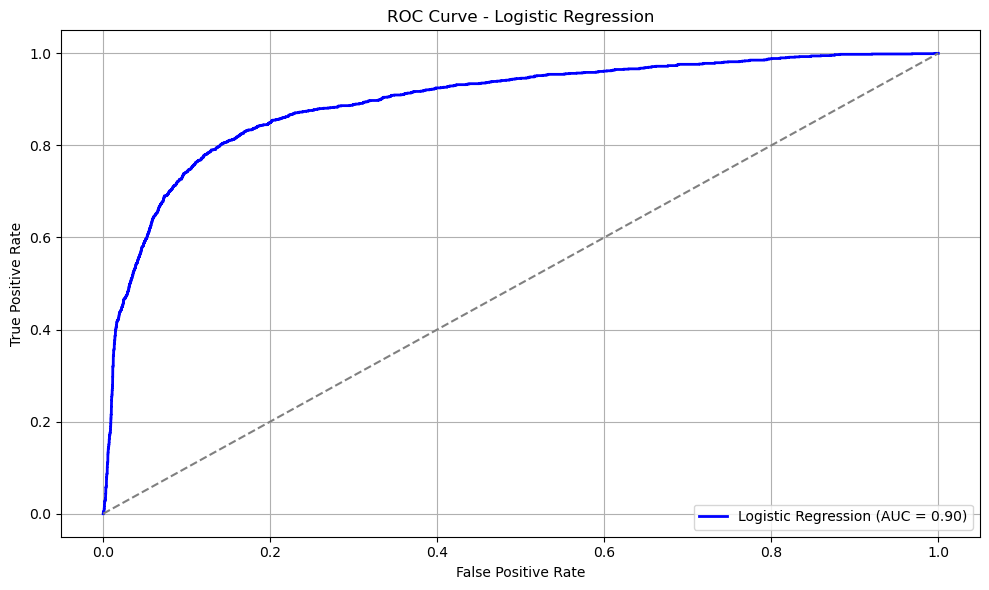

In [21]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Compute ROC curve and AUC for Logistic Regression
fpr, tpr, thresholds = roc_curve(y_val, lr_model.predict_proba(X_val_top_scaled)[:, 1])
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Logistic Regression (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

## 5.2 LightGBM

In [13]:
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(random_state=42)
lgb_model.fit(X_train_top, y_train_smote)

y_val_pred_lgb = lgb_model.predict(X_val_top)
y_val_proba_lgb = lgb_model.predict_proba(X_val_top)[:, 1]

print("Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred_lgb))
print("Classification Report:\n", classification_report(y_val, y_val_pred_lgb))
print("ROC-AUC Score:", roc_auc_score(y_val, y_val_proba_lgb))


[LightGBM] [Info] Number of positive: 50293, number of negative: 50293
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.025587 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7247
[LightGBM] [Info] Number of data points in the train set: 100586, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Confusion Matrix:
 [[11865   709]
 [  379  1047]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.94      0.96     12574
           1       0.60      0.73      0.66      1426

    accuracy                           0.92     14000
   macro avg       0.78      0.84      0.81     14000
weighted avg       0.93      0.92      0.93     14000

ROC-AUC Score: 0.9326962502601708


In [22]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from lightgbm import LGBMClassifier
import numpy as np

# Define Stratified K-Fold for balanced splits
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression Cross-Validation
lr_cv_scores = cross_val_score(
    estimator=lr_model, 
    X=X_train_top_scaled, 
    y=y_train_smote, 
    scoring='roc_auc', 
    cv=cv,
    n_jobs=-1
)
print("Logistic Regression Cross-Validation ROC-AUC Scores:", lr_cv_scores)
print("Mean ROC-AUC Score (Logistic Regression):", lr_cv_scores.mean())

# LightGBM Cross-Validation
lgb_model_cv = LGBMClassifier(
    num_leaves=31, 
    learning_rate=0.1, 
    n_estimators=100, 
    subsample=0.8, 
    colsample_bytree=0.8, 
    random_state=42
)

lgb_cv_scores = cross_val_score(
    estimator=lgb_model_cv,
    X=X_train_top_scaled,
    y=y_train_smote,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1
)
print("LightGBM Cross-Validation ROC-AUC Scores:", lgb_cv_scores)
print("Mean ROC-AUC Score (LightGBM):", lgb_cv_scores.mean())


Logistic Regression Cross-Validation ROC-AUC Scores: [0.91400667 0.91562817 0.91377662 0.91422865 0.91274319]
Mean ROC-AUC Score (Logistic Regression): 0.9140766603840073
LightGBM Cross-Validation ROC-AUC Scores: [0.98405358 0.9851054  0.98535134 0.98517131 0.98494896]
Mean ROC-AUC Score (LightGBM): 0.9849261160802886


ROC-AUC Score (LightGBM): 0.9326962502601708


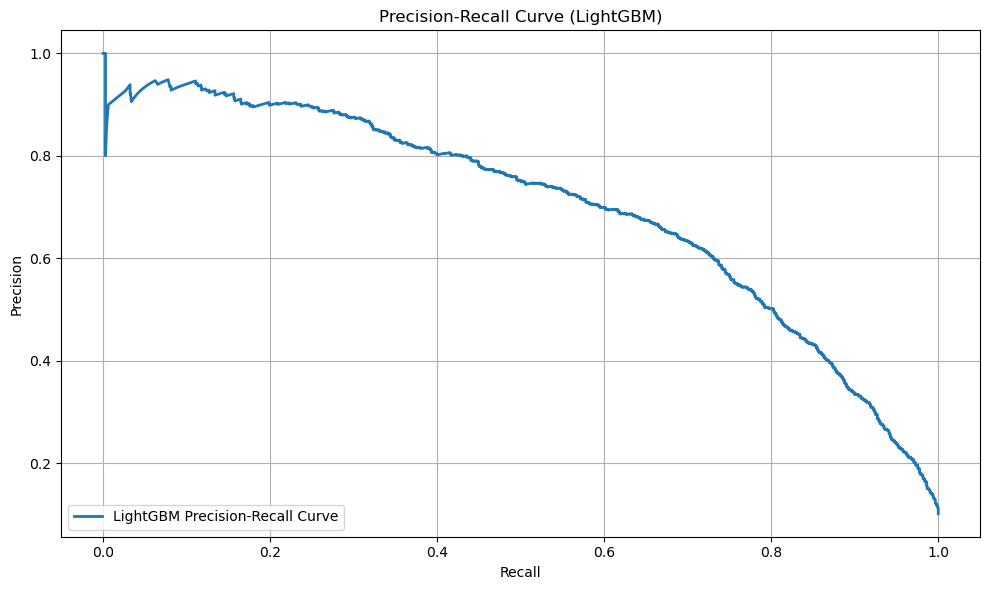

<Figure size 1200x800 with 0 Axes>

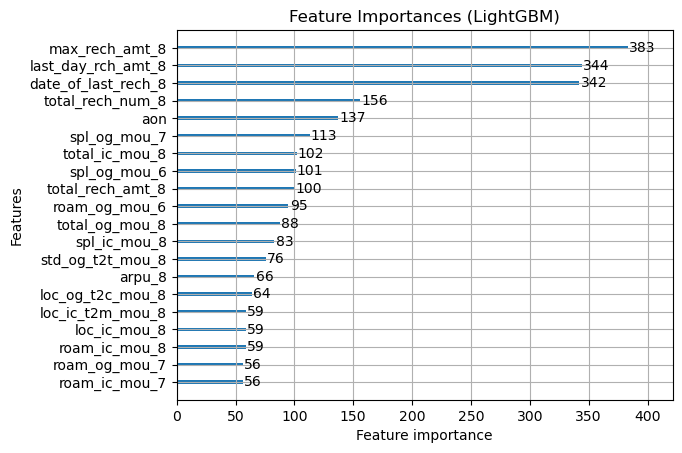

In [24]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve
import matplotlib.pyplot as plt

# Predict on validation data
y_val_pred_lgb = lgb_model.predict(X_val_top_scaled)
y_val_pred_proba_lgb = lgb_model.predict_proba(X_val_top_scaled)[:, 1]

# ROC-AUC Score
roc_auc_lgb = roc_auc_score(y_val, y_val_pred_proba_lgb)
print("ROC-AUC Score (LightGBM):", roc_auc_lgb)

# Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_val, y_val_pred_proba_lgb)

# Plot Precision-Recall Curve
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, label="LightGBM Precision-Recall Curve", linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (LightGBM)")
plt.legend(loc="lower left")
plt.grid(True)
plt.tight_layout()
plt.show()

# Feature Importance Plot
import lightgbm as lgb

plt.figure(figsize=(12, 8))
lgb.plot_importance(lgb_model, max_num_features=20, importance_type="split", title="Feature Importances (LightGBM)")
plt.show()

# 5.3 Random Forest

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Train Random Forest with the top features dataset
rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_estimators=100,
    n_jobs=-1
)

# Train on X_train_top (selected top features after SMOTE)
rf_model.fit(X_train_top_scaled, y_train_smote)

# Evaluate on validation set
y_val_pred_rf = rf_model.predict(X_val_top_scaled)
y_val_pred_proba_rf = rf_model.predict_proba(X_val_top_scaled)[:, 1]

# Print metrics
print("Confusion Matrix (Random Forest):\n", confusion_matrix(y_val, y_val_pred_rf))
print("Classification Report (Random Forest):\n", classification_report(y_val, y_val_pred_rf))
print("ROC-AUC Score (Random Forest):", roc_auc_score(y_val, y_val_pred_proba_rf))


Confusion Matrix (Random Forest):
 [[11979   595]
 [  417  1009]]
Classification Report (Random Forest):
               precision    recall  f1-score   support

           0       0.97      0.95      0.96     12574
           1       0.63      0.71      0.67      1426

    accuracy                           0.93     14000
   macro avg       0.80      0.83      0.81     14000
weighted avg       0.93      0.93      0.93     14000

ROC-AUC Score (Random Forest): 0.9313247900619079


In [32]:
# Cross-validation for Random Forest
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv_scores = cross_val_score(
    estimator=rf_model,
    X=X_train_top_scaled,
    y=y_train_smote,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1
)

print("Random Forest Cross-Validation ROC-AUC Scores:", rf_cv_scores)
print("Mean ROC-AUC Score (Random Forest):", rf_cv_scores.mean())

Random Forest Cross-Validation ROC-AUC Scores: [0.98655338 0.98695999 0.98641977 0.98709768 0.98672397]
Mean ROC-AUC Score (Random Forest): 0.9867509576963178


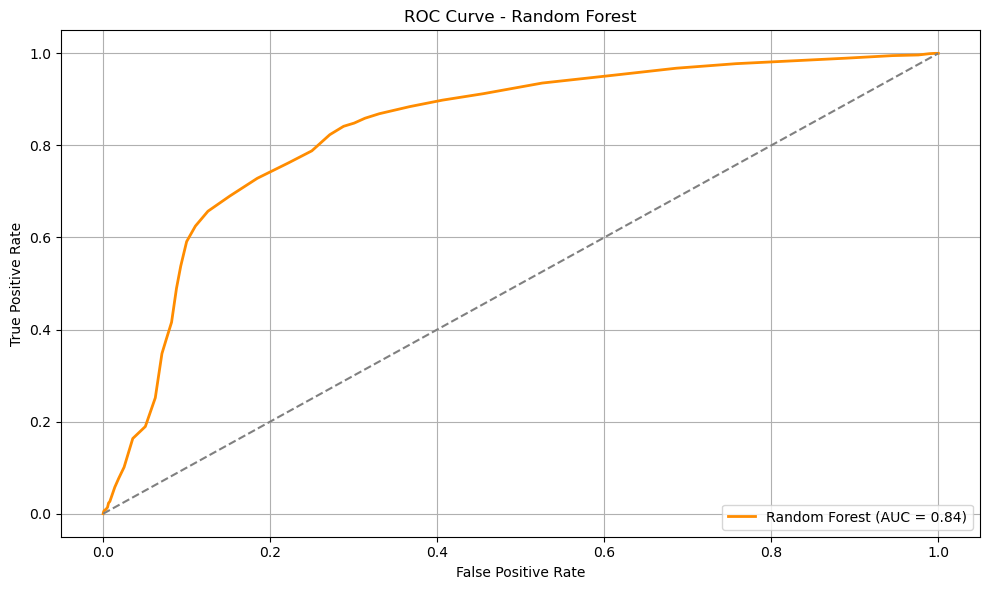

In [33]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Compute ROC curve and AUC for Random Forest
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_val, rf_model.predict_proba(X_val_top)[:, 1])
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plot ROC Curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f"Random Forest (AUC = {roc_auc_rf:.2f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


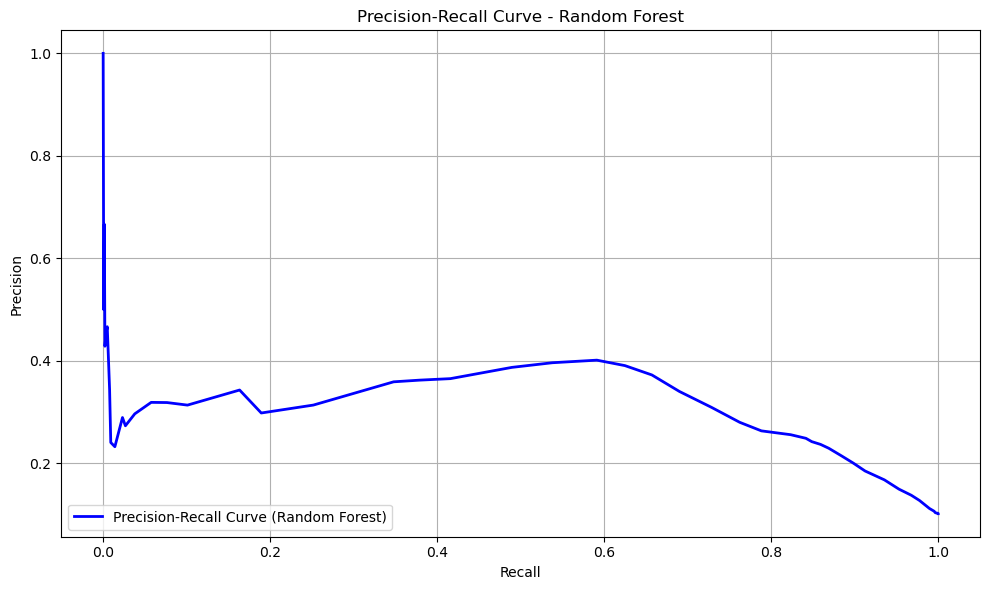

In [34]:
from sklearn.metrics import precision_recall_curve

# Compute Precision-Recall curve for Random Forest
precision_rf, recall_rf, thresholds_rf_pr = precision_recall_curve(y_val, rf_model.predict_proba(X_val_top)[:, 1])

# Plot Precision-Recall Curve
plt.figure(figsize=(10, 6))
plt.plot(recall_rf, precision_rf, color='blue', lw=2, label="Precision-Recall Curve (Random Forest)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Random Forest")
plt.legend(loc="lower left")
plt.grid(True)
plt.tight_layout()
plt.show()


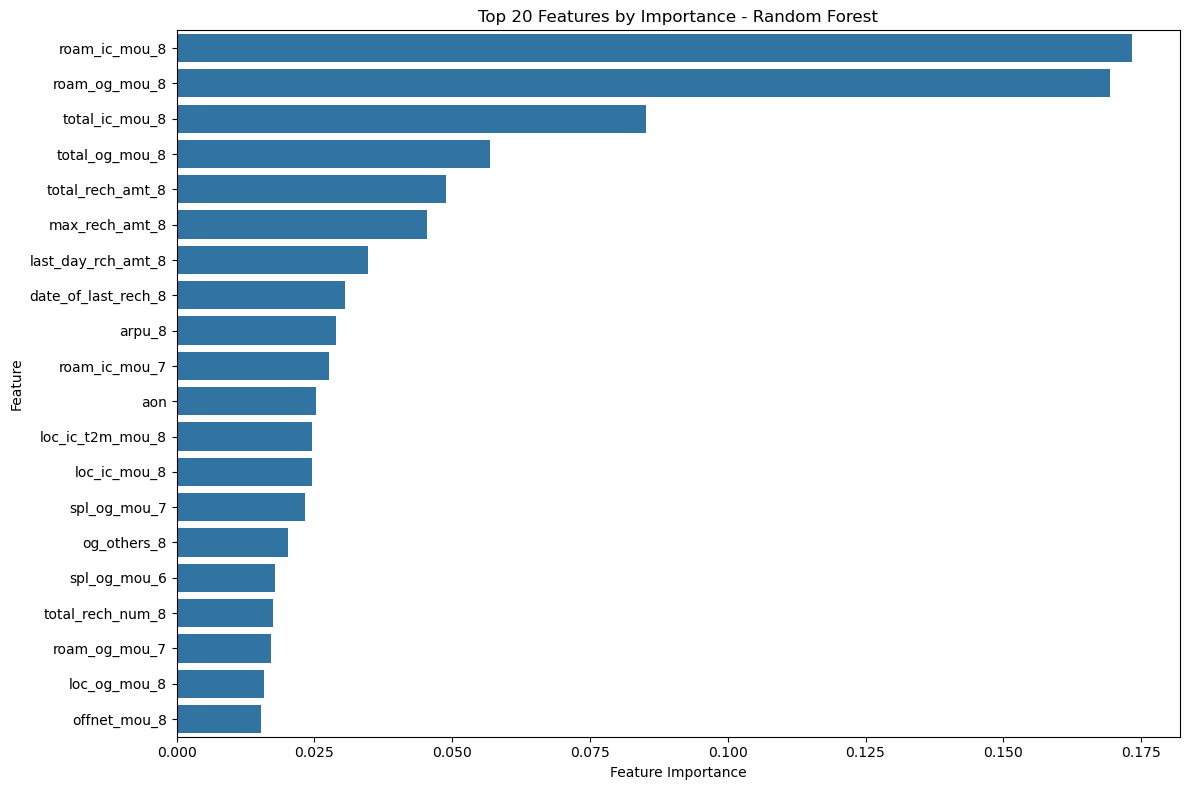

In [35]:
import pandas as pd
import seaborn as sns

# Extract feature importance from the Random Forest model
rf_feature_importance = pd.DataFrame({
    'Feature': X_train_top.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot Top 20 Features
plt.figure(figsize=(12, 8))
sns.barplot(x=rf_feature_importance['Importance'][:20], y=rf_feature_importance['Feature'][:20])
plt.title("Top 20 Features by Importance - Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 5.4 XGBoost

In [40]:
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Train XGBoost
xgb_model = XGBClassifier(random_state=42, scale_pos_weight=10)
xgb_model.fit(X_train_top_scaled, y_train_smote)  # Use scaled top features

# Evaluate XGBoost using `X_val_top_scaled`
y_val_pred = xgb_model.predict(X_val_top_scaled)
y_val_pred_proba = xgb_model.predict_proba(X_val_top_scaled)[:, 1]

print("XGBoost Classification Report:\n", classification_report(y_val, y_val_pred))
print("XGBoost ROC-AUC Score:", roc_auc_score(y_val, y_val_pred_proba))

# Perform cross-validation on XGBoost
xgb_cv_scores = cross_val_score(
    estimator=xgb_model,
    X=X_train_top_scaled,  # Ensure consistency with the scaled dataset
    y=y_train_smote,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1
)

print("XGBoost Cross-Validation ROC-AUC Scores:", xgb_cv_scores)
print("Mean ROC-AUC Score (XGBoost):", xgb_cv_scores.mean())


XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.87      0.92     12574
           1       0.44      0.85      0.58      1426

    accuracy                           0.87     14000
   macro avg       0.71      0.86      0.75     14000
weighted avg       0.93      0.87      0.89     14000

XGBoost ROC-AUC Score: 0.9313892053573003
XGBoost Cross-Validation ROC-AUC Scores: [0.987264   0.98741908 0.98698851 0.98813358 0.98742971]
Mean ROC-AUC Score (XGBoost): 0.9874469771545196


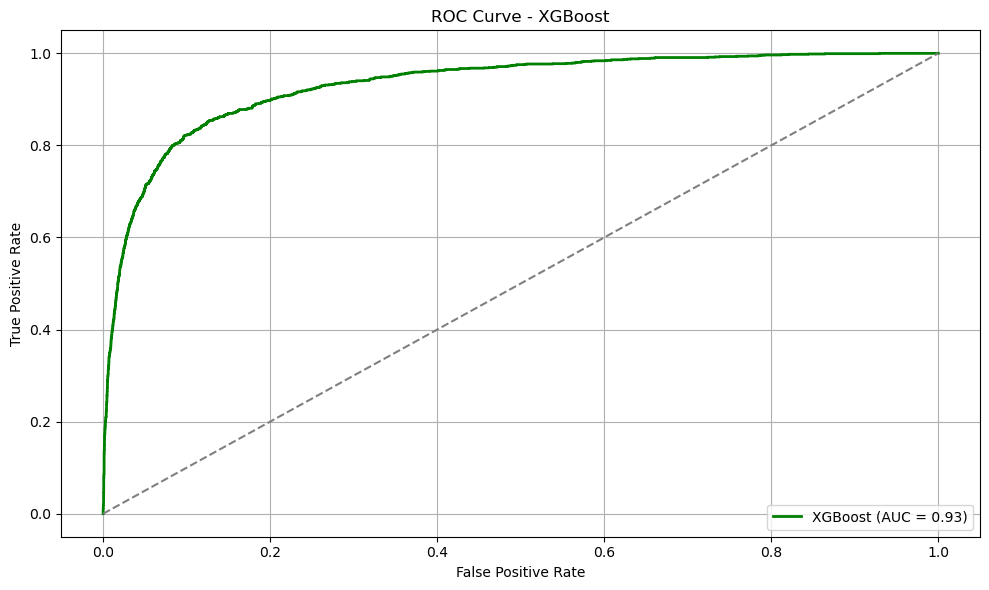

In [41]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Compute ROC curve and AUC for the trained XGBoost model
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_val, xgb_model.predict_proba(X_val_top_scaled)[:, 1])
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plot the ROC Curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_xgb, tpr_xgb, color='green', lw=2, label=f"XGBoost (AUC = {roc_auc_xgb:.2f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title("ROC Curve - XGBoost")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


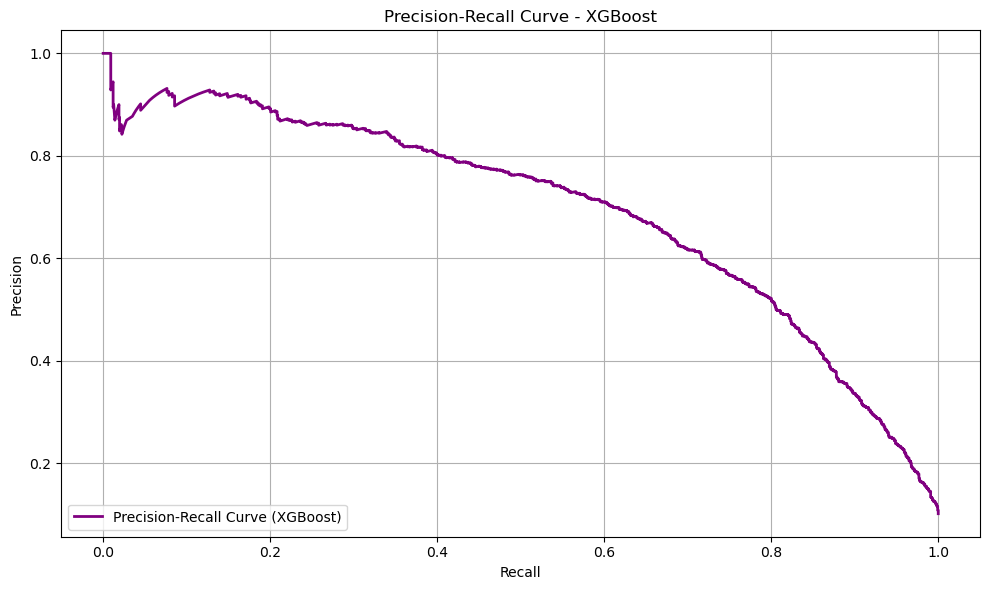

In [43]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Compute Precision-Recall curve for XGBoost
precision_xgb, recall_xgb, thresholds_xgb_pr = precision_recall_curve(y_val, xgb_model.predict_proba(X_val_top_scaled)[:, 1])

# Plot Precision-Recall Curve
plt.figure(figsize=(10, 6))
plt.plot(recall_xgb, precision_xgb, color='purple', lw=2, label="Precision-Recall Curve (XGBoost)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - XGBoost")
plt.legend(loc="lower left")
plt.grid(True)
plt.tight_layout()
plt.show()


<Figure size 1200x800 with 0 Axes>

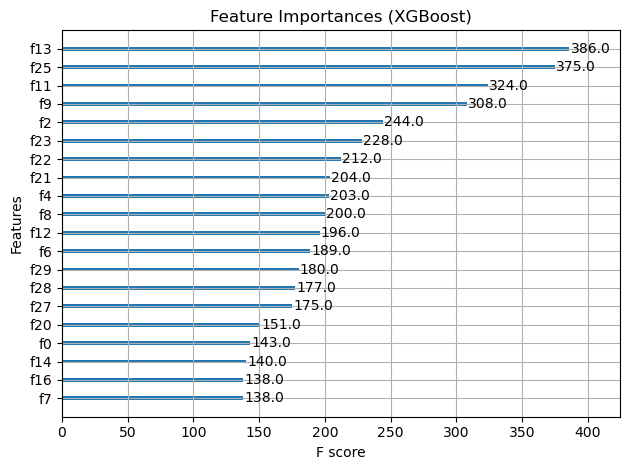

In [44]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

# Plot Feature Importance using XGBoost's built-in method
plt.figure(figsize=(12, 8))
plot_importance(xgb_model, max_num_features=20, importance_type='weight', title='Feature Importances (XGBoost)')
plt.tight_layout()
plt.show()


# Step 6: Hyperparameter Tuning

## 6.1 Bayesian Optimization

In [31]:
from skopt import BayesSearchCV

# Define Bayesian Search Space
search_space = {
    'n_estimators': (50, 300),
    'learning_rate': (0.01, 0.3, 'log-uniform'),
    'max_depth': (3, 10),
    'subsample': (0.6, 1.0),
    'colsample_bytree': (0.6, 1.0)
}

# Bayesian SearchCV for XGBoost
bayes_search_xgb = BayesSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False),
    search_spaces=search_space,
    scoring='roc_auc',
    cv=3,
    n_iter=30,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
bayes_search_xgb.fit(X_train_top, y_train_smote)
best_bayes_xgb = bayes_search_xgb.best_estimator_

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fi

In [32]:
# Print the best parameters found by Bayesian Optimization
print("Best Parameters (Bayesian Optimization - XGBoost):")
print(bayes_search_xgb.best_params_)

# Retrieve the best estimator
best_bayes_xgb = bayes_search_xgb.best_estimator_

# Evaluate the best XGBoost model on the validation set
y_val_pred_xgb = best_bayes_xgb.predict(X_val_top)
y_val_pred_proba_xgb = best_bayes_xgb.predict_proba(X_val_top)[:, 1]

# Print detailed evaluation metrics
print("\nConfusion Matrix (XGBoost):\n", confusion_matrix(y_val, y_val_pred_xgb))
print("\nClassification Report (XGBoost):\n", classification_report(y_val, y_val_pred_xgb))
print("\nROC-AUC Score (XGBoost):", roc_auc_score(y_val, y_val_pred_proba_xgb))

Best Parameters (Bayesian Optimization - XGBoost):
OrderedDict({'colsample_bytree': 0.6, 'learning_rate': 0.12556919817798176, 'max_depth': 10, 'n_estimators': 300, 'subsample': 1.0})

Confusion Matrix (XGBoost):
 [[12053   521]
 [  471   955]]

Classification Report (XGBoost):
               precision    recall  f1-score   support

           0       0.96      0.96      0.96     12574
           1       0.65      0.67      0.66      1426

    accuracy                           0.93     14000
   macro avg       0.80      0.81      0.81     14000
weighted avg       0.93      0.93      0.93     14000


ROC-AUC Score (XGBoost): 0.935257831840274


In [34]:
xgb_cv_scores = cross_val_score(
    estimator=best_bayes_xgb,
    X=X_train_top,
    y=y_train_smote,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1
)
print("Cross-Validation ROC-AUC Scores (XGBoost):", xgb_cv_scores)
print("Mean ROC-AUC Score (XGBoost):", xgb_cv_scores.mean())


Cross-Validation ROC-AUC Scores (XGBoost): [0.98078656 0.99456121 0.99498918]
Mean ROC-AUC Score (XGBoost): 0.9901123166904949


## 6.2 AdaBoost

In [35]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from skopt import BayesSearchCV
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Define Bayesian Search Space for AdaBoost
search_space_adaboost = {
    'n_estimators': (50, 300),
    'learning_rate': (0.01, 1.0, 'log-uniform'),
    'estimator__max_depth': (1, 10)  # Use 'estimator__' to set parameters for the base estimator
}

# Initialize AdaBoost with Decision Tree Base Estimator
adaboost = AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=42), random_state=42)

# Bayesian SearchCV for AdaBoost
bayes_search_adaboost = BayesSearchCV(
    estimator=adaboost,
    search_spaces=search_space_adaboost,
    scoring='roc_auc',
    cv=3,
    n_iter=30,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Fit Bayesian SearchCV
bayes_search_adaboost.fit(X_train_top, y_train_smote)

# Retrieve the best model
best_adaboost = bayes_search_adaboost.best_estimator_

# Evaluate the tuned AdaBoost model on the validation set
y_val_pred_adaboost = best_adaboost.predict(X_val_top)
y_val_pred_proba_adaboost = best_adaboost.predict_proba(X_val_top)[:, 1]

# Print evaluation metrics for AdaBoost
print("Best Parameters (Bayesian Optimization - AdaBoost):", bayes_search_adaboost.best_params_)
print("\nConfusion Matrix (AdaBoost):\n", confusion_matrix(y_val, y_val_pred_adaboost))
print("\nClassification Report (AdaBoost):\n", classification_report(y_val, y_val_pred_adaboost))
print("\nROC-AUC Score (AdaBoost):", roc_auc_score(y_val, y_val_pred_proba_adaboost))


Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fi

C:\Users\RAGHAVENDRA\AppData\Roaming\Python\Python312\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Best Parameters (Bayesian Optimization - AdaBoost): OrderedDict({'estimator__max_depth': 10, 'learning_rate': 0.058372665563595626, 'n_estimators': 298})

Confusion Matrix (AdaBoost):
 [[12026   548]
 [  477   949]]

Classification Report (AdaBoost):
               precision    recall  f1-score   support

           0       0.96      0.96      0.96     12574
           1       0.63      0.67      0.65      1426

    accuracy                           0.93     14000
   macro avg       0.80      0.81      0.80     14000
weighted avg       0.93      0.93      0.93     14000


ROC-AUC Score (AdaBoost): 0.9044230943836331


## 6.3 Bayesian Optimization for LightGBM

In [36]:
from lightgbm import LGBMClassifier
from skopt import BayesSearchCV
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Define Bayesian Search Space for LightGBM
search_space_lgbm = {
    'num_leaves': (15, 50),  # Range of leaf nodes
    'learning_rate': (0.01, 0.3, 'log-uniform'),  # Logarithmic scale for learning rates
    'n_estimators': (50, 300),  # Number of boosting iterations
    'subsample': (0.6, 1.0),  # Fraction of samples for each boosting round
    'colsample_bytree': (0.6, 1.0),  # Fraction of features for each boosting round
    'max_depth': (3, 15)  # Maximum depth of the trees
}

# Initialize LightGBM Classifier
lgbm = LGBMClassifier(random_state=42)

# Bayesian SearchCV for LightGBM
bayes_search_lgbm = BayesSearchCV(
    estimator=lgbm,
    search_spaces=search_space_lgbm,
    scoring='roc_auc',
    cv=3,
    n_iter=30,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Fit Bayesian SearchCV
bayes_search_lgbm.fit(X_train_top_scaled, y_train_smote)

# Retrieve the best model
best_lgbm = bayes_search_lgbm.best_estimator_

# Evaluate the tuned LightGBM model on the validation set
y_val_pred_lgbm = best_lgbm.predict(X_val_top_scaled)
y_val_pred_proba_lgbm = best_lgbm.predict_proba(X_val_top_scaled)[:, 1]

# Print evaluation metrics for LightGBM
print("Best Parameters (Bayesian Optimization - LightGBM):", bayes_search_lgbm.best_params_)
print("\nConfusion Matrix (LightGBM):\n", confusion_matrix(y_val, y_val_pred_lgbm))
print("\nClassification Report (LightGBM):\n", classification_report(y_val, y_val_pred_lgbm))
print("\nROC-AUC Score (LightGBM):", roc_auc_score(y_val, y_val_pred_proba_lgbm))


Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fi

## Bayesian Optimization for Random Forest

In [28]:
from sklearn.ensemble import RandomForestClassifier
from skopt import BayesSearchCV
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Define Bayesian Search Space for Random Forest
search_space_rf = {
    'n_estimators': (50, 300),  # Number of trees in the forest
    'max_depth': (5, 20),  # Maximum depth of the tree
    'min_samples_split': (2, 10),  # Minimum number of samples required to split an internal node
    'min_samples_leaf': (1, 10),  # Minimum number of samples required to be at a leaf node
    'max_features': (0.6, 1.0, 'uniform')  # Fraction of features to consider for splitting
}

# Initialize Random Forest Classifier
rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

# Bayesian SearchCV for Random Forest
bayes_search_rf = BayesSearchCV(
    estimator=rf,
    search_spaces=search_space_rf,
    scoring='roc_auc',
    cv=3,
    n_iter=30,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Fit Bayesian SearchCV
bayes_search_rf.fit(X_train_top, y_train_smote)

# Retrieve the best model
best_rf = bayes_search_rf.best_estimator_

# Evaluate the tuned Random Forest model on the validation set
y_val_pred_rf = best_rf.predict(X_val_top)
y_val_pred_proba_rf = best_rf.predict_proba(X_val_top)[:, 1]

# Print evaluation metrics for Random Forest
print("Best Parameters (Bayesian Optimization - Random Forest):", bayes_search_rf.best_params_)
print("\nConfusion Matrix (Random Forest):\n", confusion_matrix(y_val, y_val_pred_rf))
print("\nClassification Report (Random Forest):\n", classification_report(y_val, y_val_pred_rf))
print("\nROC-AUC Score (Random Forest):", roc_auc_score(y_val, y_val_pred_proba_rf))


Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fi

# Step 7: Ensemble Learning
Objective: Combine multiple models for improved performances.

In [47]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Base estimators (Ensure all models are reinitialized if flushed from memory)
base_estimators = [
    ('Logistic Regression', Pipeline([
        ('scaler', StandardScaler()),  # Scale for Logistic Regression
        ('lr', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
    ])),
    ('Random Forest', best_rf),          
    ('XGBoost', best_bayes_xgb),         
    ('LightGBM', best_lgbm),             
    ('AdaBoost', best_adaboost)          
]

# Meta-classifier (Logistic Regression)
meta_classifier = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

# Define Stacking Classifier
stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_classifier,
    passthrough=True,  # Include original features in meta-classifier
    cv=5               # Use cross-validation for meta-classifier training
)

# Train the Stacking Classifier
print("Training Stacking Classifier...")
stacking_model.fit(X_train_top_scaled, y_train_smote)

# Evaluate the Stacking Classifier
y_val_pred_stack = stacking_model.predict(X_val_top_scaled)
y_val_proba_stack = stacking_model.predict_proba(X_val_top_scaled)[:, 1]

# Print evaluation metrics
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
print("\nConfusion Matrix (Stacking Classifier):\n", confusion_matrix(y_val, y_val_pred_stack))
print("\nClassification Report (Stacking Classifier):\n", classification_report(y_val, y_val_pred_stack))
print("\nROC-AUC Score (Stacking Classifier):", roc_auc_score(y_val, y_val_proba_stack))


Training Stacking Classifier...
[LightGBM] [Info] Number of positive: 50293, number of negative: 50293
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015742 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7247
[LightGBM] [Info] Number of data points in the train set: 100586, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


C:\Users\RAGHAVENDRA\AppData\Roaming\Python\Python312\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


[LightGBM] [Info] Number of positive: 40234, number of negative: 40234
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.041160 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7243
[LightGBM] [Info] Number of data points in the train set: 80468, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 40235, number of negative: 40234
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.021109 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7244
[LightGBM] [Info] Number of data points in the train set: 80469, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500006 -> initscore=0.000025
[LightGBM] [Info] Start training from score 0.000025
[LightGBM] [Info] Number of positive: 40235, number of negative: 4023

C:\Users\RAGHAVENDRA\AppData\Roaming\Python\Python312\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\RAGHAVENDRA\AppData\Roaming\Python\Python312\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\RAGHAVENDRA\AppData\Roaming\Python\Python312\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\RAGHAVENDRA\AppData\Roaming\Python\Python312\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will 


Confusion Matrix (Stacking Classifier):
 [[11912   662]
 [  399  1027]]

Classification Report (Stacking Classifier):
               precision    recall  f1-score   support

           0       0.97      0.95      0.96     12574
           1       0.61      0.72      0.66      1426

    accuracy                           0.92     14000
   macro avg       0.79      0.83      0.81     14000
weighted avg       0.93      0.92      0.93     14000


ROC-AUC Score (Stacking Classifier): 0.9278341224160542


# Step 8: Comparing Ensemble Methods

Compare the performance of Voting Classifier, Stacking Classifier, and individual models (Logistic Regression, Random Forest, XGBoost AdaBoost).


Model Comparison:

               Model  Accuracy   ROC-AUC  Precision (Class 1)  \
0      Random Forest  0.694357  0.810185             0.227819   
1            XGBoost  0.896786  0.587634             0.358209   
2           AdaBoost  0.903000  0.920485             0.516473   
3           LightGBM  0.922857  0.933421             0.599769   
4  Voting Classifier  0.913714  0.937540             0.554446   

   Recall (Class 1)  F1-Score (Class 1)  
0          0.837307            0.358182  
1          0.016830            0.032150  
2          0.747546            0.610888  
3          0.729313            0.658228  
4          0.778401            0.647608  


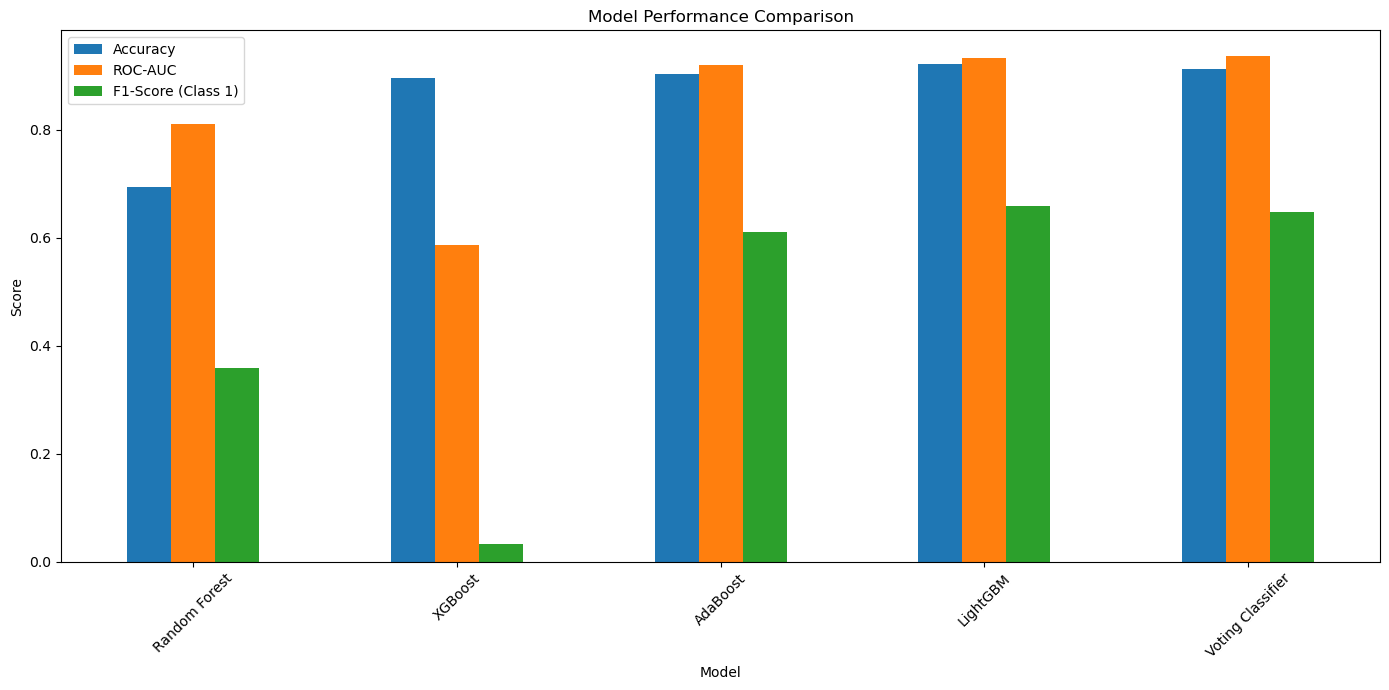

In [48]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import pandas as pd

# Define models for comparison
models = {
    'Random Forest': best_rf,
    'XGBoost': best_bayes_xgb,
    'AdaBoost': best_adaboost,
    'LightGBM': best_lgbm,
    'Voting Classifier': voting_model
}

# Evaluate models
results = []

for name, model in models.items():
    # Use scaled inputs if applicable
    X_val_input = X_val_top_scaled if name in ['Voting Classifier', 'AdaBoost', 'LightGBM'] else X_val_top
    
    # Predict and calculate probabilities
    y_val_pred = model.predict(X_val_input)
    try:
        y_val_pred_proba = model.predict_proba(X_val_input)[:, 1]
    except AttributeError:
        # Fallback for models without predict_proba (not expected in this case)
        y_val_pred_proba = None

    # Metrics
    accuracy = accuracy_score(y_val, y_val_pred)
    roc_auc = roc_auc_score(y_val, y_val_pred_proba) if y_val_pred_proba is not None else None
    report = classification_report(y_val, y_val_pred, output_dict=True)
    
    # Append results
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'ROC-AUC': roc_auc,
        'Precision (Class 1)': report['1']['precision'],
        'Recall (Class 1)': report['1']['recall'],
        'F1-Score (Class 1)': report['1']['f1-score']
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Display results
print("\nModel Comparison:\n")
print(results_df)

# Plot performance comparison
results_df.set_index('Model')[['Accuracy', 'ROC-AUC', 'F1-Score (Class 1)']].plot.bar(figsize=(14, 7))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Step 9: Threshold Tuning for Optimal Precision-Recall Trade-Off
Objective: Adjust the threshold for optimal precision-recall trade-off.

Optimal Threshold (F1-Score): 0.64

Confusion Matrix:
 [[12077   497]
 [  448   978]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96     12574
           1       0.66      0.69      0.67      1426

    accuracy                           0.93     14000
   macro avg       0.81      0.82      0.82     14000
weighted avg       0.93      0.93      0.93     14000

ROC-AUC Score: 0.9375


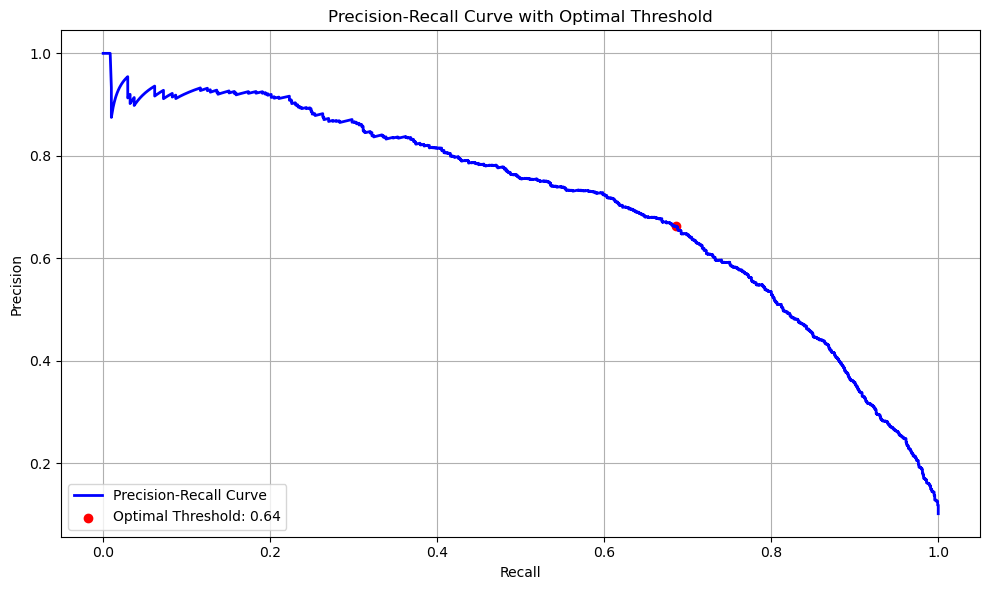

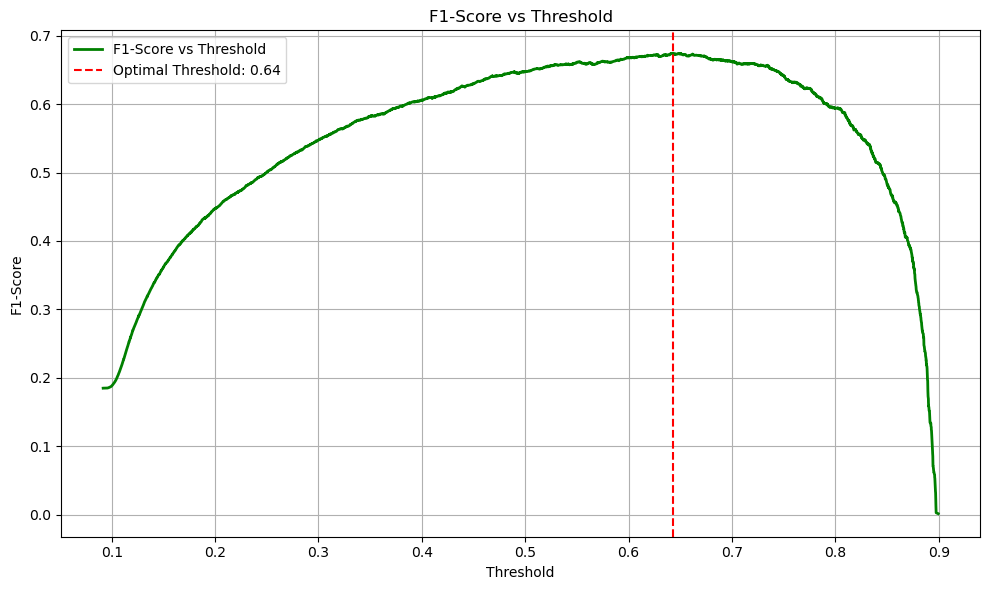

In [49]:
from sklearn.metrics import precision_recall_curve, accuracy_score, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Predict probabilities for the validation set
y_val_proba = voting_model.predict_proba(X_val_top_scaled)[:, 1]

# Compute Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_val, y_val_proba)

# Handle potential edge case: If no thresholds are generated
if len(thresholds) == 0:
    raise ValueError("No thresholds were generated. Check your model or data.")

# Calculate F1 scores for all thresholds
f1_scores = 2 * (precision * recall) / (precision + recall)
f1_scores = np.nan_to_num(f1_scores)  # Replace NaN values with 0

# Identify the optimal threshold (maximum F1-Score)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal Threshold (F1-Score): {optimal_threshold:.2f}")

# Adjust predictions using the optimal threshold
y_val_pred_adjusted = (y_val_proba >= optimal_threshold).astype(int)

# Evaluate adjusted predictions
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_val_pred_adjusted))
print("\nClassification Report:\n", classification_report(y_val, y_val_pred_adjusted))
print(f"ROC-AUC Score: {roc_auc_score(y_val, y_val_proba):.4f}")

# Plot Precision-Recall Curve
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, label="Precision-Recall Curve", linewidth=2, color='blue')
plt.scatter(recall[optimal_idx], precision[optimal_idx], color='red', label=f"Optimal Threshold: {optimal_threshold:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve with Optimal Threshold")
plt.legend(loc="lower left")
plt.grid(True)
plt.tight_layout()
plt.show()

# Optional: Plot F1-Score vs. Threshold
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores[:-1], label="F1-Score vs Threshold", color='green', linewidth=2)  # Exclude last threshold
plt.axvline(optimal_threshold, color='red', linestyle="--", label=f"Optimal Threshold: {optimal_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("F1-Score")
plt.title("F1-Score vs Threshold")
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()


In [50]:
import joblib

# Save models to files
joblib.dump(voting_model, "voting_model.pkl")
joblib.dump(stacking_model, "stacking_model.pkl")
joblib.dump(best_rf, "random_forest.pkl")
joblib.dump(best_lgbm, "lightgbm.pkl")
joblib.dump(best_adaboost, "adaboost.pkl")
joblib.dump(best_bayes_xgb, "xgboost.pkl")


['xgboost.pkl']

In [51]:
print("Voting Classifier:", voting_model)
print("Stacking Classifier:", stacking_model)
print("Random Forest:", best_rf)
print("LightGBM:", best_lgbm)
print("AdaBoost:", best_adaboost)
print("XGBoost:", best_bayes_xgb)

Voting Classifier: VotingClassifier(estimators=[('Random Forest',
                              RandomForestClassifier(max_depth=20,
                                                     max_features=0.6,
                                                     n_estimators=300,
                                                     n_jobs=-1,
                                                     random_state=42)),
                             ('XGBoost',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_me...
 

In [52]:
import joblib

# Save models with status messages
models = {
    "voting_model.pkl": voting_model,
    "stacking_model.pkl": stacking_model,
    "random_forest.pkl": best_rf,
    "lightgbm.pkl": best_lgbm,
    "adaboost.pkl": best_adaboost,
    "xgboost.pkl": best_bayes_xgb
}

saved_files = []
for filename, model in models.items():
    if model:  # Save only if the model exists
        joblib.dump(model, filename)
        saved_files.append(filename)
    else:
        print(f"Model for {filename} is not defined or None.")

print("Saved files:", saved_files)


Saved files: ['voting_model.pkl', 'stacking_model.pkl', 'random_forest.pkl', 'lightgbm.pkl', 'adaboost.pkl', 'xgboost.pkl']


In [53]:
import os
print("Saved model files:", [f for f in os.listdir() if f.endswith(".pkl")])

Saved model files: ['adaboost.pkl', 'adaboost_grid_search.pkl', 'gradient_boosting_model.pkl', 'lightgbm.pkl', 'random_forest.pkl', 'stacking_model.pkl', 'voting_model.pkl', 'xgboost.pkl']


# Step 10. Final Predictions and Submission
Objective: Predict on the test dataset and prepare the submission file.

In [91]:
# Ensure the test probabilities are generated
try:
    test_proba = voting_model.predict_proba(X_test_top_scaled)[:, 1]
except AttributeError:
    raise ValueError("Ensure `voting_model` is properly fitted before making predictions.")

# Apply the optimal threshold
if 'optimal_threshold' not in locals():
    raise ValueError("`optimal_threshold` is not defined. Please perform threshold tuning before submission.")

test_predictions = (test_proba >= optimal_threshold).astype(int)

# Create the submission DataFrame
submission = pd.DataFrame({'id': test_df['id'], 'churn_probability': test_predictions})


submission.to_csv("submission.csv", index=False)
print("Submission file created: submission.csv")

# Preview and confirmation
print("Submission File Example:")
print(submission.head())


Submission file created: submission.csv
Submission File Example:
      id  churn_probability
0  69999                  0
1  70000                  0
2  70001                  1
3  70002                  0
4  70003                  0


In [92]:
submission_check = pd.read_csv("submission_20241117_160819.csv")
print(submission_check.columns)

Index(['id', 'churn_probability'], dtype='object')
